# Chapter 2: Statistical Learning — Lab
---
> **Context**: This notebook follows the introductory lab of *Introduction to Statistical Learning with Python (ISLP)*.  
> **Objective**: Gain proficiency in the Python environment, data ingestion, and Exploratory Data Analysis (EDA).

---
## 2.3.2 Basic Commands
Testing basic Python output and variable handling.

### 1. Basic Arithmetic and String Formatting
Testing standard Python output and string concatenation using `f-strings` for better readability.

In [41]:
# f-string formatting 
n_vars = 11
print(f"Fit a model with {n_vars} variables")

# Basic arithmetic and string concatenation
print(f"Arithmetic test (3+5): {3 + 5}")
print("Hello" + " " + "world")

Fit a model with 11 variables
Arithmetic test (3+5): 8
Hello world


### 2. Introspection Tools
Using `?` to access the docstring and help menu for built-in functions. 
*Note: This is an interactive command for development.*

In [42]:
# Uncomment the line below to view the print function documentation
# print?

### 3. List Operations and Concatenation
Defining vectors as Python lists. Note that the `+` operator in standard Python performs **concatenation**, not element-wise addition.

In [43]:
# Defining two numeric lists
x = [3, 4, 5]
y = [4, 9, 7]

# Displaying x and its concatenation with y
print(f"List x: {x}")
print(f"Concatenated lists (x + y): {x + y}")

List x: [3, 4, 5]
Concatenated lists (x + y): [3, 4, 5, 4, 9, 7]


---
## 2.3.3 Introduction to Numerical Python (NumPy)
`NumPy` is the foundational library for scientific computing in Python. Unlike standard lists, NumPy arrays enable **vectorization**, allowing for high-performance mathematical operations on large datasets.

### 1. Array Creation and Metadata
In this section, we transition from standard Python lists to **NumPy arrays (ndarrays)**. We explore array creation, data types (`dtype`), and structural attributes like `shape` and `ndim`.

In [44]:
# 1. Import the NumPy library
import numpy as np

# 2. Create two NumPy arrays from the lists x and y
x = np.array([3, 4, 5])
y = np.array([4, 9, 7])

# 3. Display the arrays and their element-wise sum
print(f"x + y: {x + y}")

# 4. Create a 2D NumPy array (matrix) and display it
x = np.array([[1, 2], [3, 4]])
print(f"Matrix x:\n{x}")

# 5. Display the number of dimensions of the array
print(f"Dimensions: {x.ndim}")

# 6. Display the shape of the array
print(f"Shape: {x.shape}")

# 7. Display the data type of the array
print(f"Dtype: {x.dtype}")

# 8. Create a new array with mixed data types and display its data type
print(f"Mixed dtype: {np.array([[1, 2], [3.0, 4]]).dtype}")

# 9. View the documentation for the NumPy array function
# np.array?

# 10. Create a new array with a specified data type and display its data type
print(f"Forced float dtype: {np.array([[1, 2], [3, 4]], float).dtype}")

# 11. Display the shape of the original array x
print(f"Current shape: {x.shape}")

x + y: [ 7 13 12]
Matrix x:
[[1 2]
 [3 4]]
Dimensions: 2
Shape: (2, 2)
Dtype: int64
Mixed dtype: float64
Forced float dtype: float64
Current shape: (2, 2)


### 2. Reshaping and Memory Indexing
Numerical arrays can be reshaped to fit model requirements. It is critical to note that reshaping often creates a **view**, meaning modifications to the reshaped array will affect the original data.

In [45]:
# 12. Create a new array and compute its sum using the NumPy sum function
x = np.array([1, 2, 3, 4])
print(f"Sum: {x.sum()}")

# 13. Re-assign and compute sum using np.sum()
x = np.array([1, 2, 3, 4])
print(f"NP Sum: {np.sum(x)}")

# 14. Create an array for reshaping
x = np.array([1, 2, 3, 4, 5, 6])
print('Beginning x:\n', x)

# 15. Reshape the array x to (2, 3)
x_reshape = x.reshape((2, 3))
print('Reshaped x:\n', x_reshape)

# 16. Access element (row 0, col 0)
print(f"Element [0,0]: {x_reshape[0, 0]}")

# 17. Access element (row 1, col 2)
print(f"Element [1,2]: {x_reshape[1, 2]}")

# 18. Demonstrate that modifying a view modifies the original array
print('x before modification:\n', x)
x_reshape[0, 0] = 5
print('x after modifying x_reshape[0,0]:\n', x)

Sum: 10
NP Sum: 10
Beginning x:
 [1 2 3 4 5 6]
Reshaped x:
 [[1 2 3]
 [4 5 6]]
Element [0,0]: 1
Element [1,2]: 6
x before modification:
 [1 2 3 4 5 6]
x after modifying x_reshape[0,0]:
 [5 2 3 4 5 6]


### Tuples vs. Arrays: Understanding Immutability
Unlike NumPy arrays, Python **tuples** are immutable. Attempting to modify them will result in a `TypeError`.

In [46]:
# 19-20. Demonstrate Tuple immutability
my_tuple = (3, 4, 5)
try:
    my_tuple[0] = 2
except TypeError as e:
    print(f"Expected Error: {e}")

# 21. Display attributes and Transpose
print(f"Shape: {x_reshape.shape}, Ndim: {x_reshape.ndim}")
print(f"Transpose:\n{x_reshape.T}")

Expected Error: 'tuple' object does not support item assignment
Shape: (2, 3), Ndim: 2
Transpose:
[[5 4]
 [2 5]
 [3 6]]


### Element-wise Mathematical Operations
NumPy provides optimized functions for universal transformations (Square root, Exponentiation).

In [47]:
# Re-define x locally to keep this cell independent from previous state
x = np.array([1, 2, 3, 4, 5, 6])

# 22. Square root
print(f"Sqrt: {np.sqrt(x)}")

# 23. Square
print(f"Square: {x**2}")

# 24. Sqrt using exponentiation
print(f"Sqrt (x**0.5): {x**0.5}")

Sqrt: [1.         1.41421356 1.73205081 2.         2.23606798 2.44948974]
Square: [ 1  4  9 16 25 36]
Sqrt (x**0.5): [1.         1.41421356 1.73205081 2.         2.23606798 2.44948974]


### Random Number Generation and Correlation
Statistical simulations require random draws. In this section, we first contrast unseeded randomness (different outputs on each call) with seeded generators (`default_rng`) for reproducible results.

In [48]:
# 25. Standard normal distribution sample (n=50)
x = np.random.normal(size=50)

# 26. Add noise to create a related variable
y = x + np.random.normal(loc=50, scale=1, size=50)

# 27. Correlation coefficient matrix
print(f"Correlation Matrix:\n{np.corrcoef(x, y)}")

# 28. Unseeded randomness: outputs vary from one call to the next
print(f"Unseeded sample 1: {np.random.normal(scale=5, size=2)}")
print(f"Unseeded sample 2: {np.random.normal(scale=5, size=2)}")

# 29. Seeded randomness with default_rng: same seed -> same output
rng = np.random.default_rng(1303)
print(f"Seeded RNG 1: {rng.normal(scale=5, size=2)}")
rng2 = np.random.default_rng(1303)
print(f"Seeded RNG 2 (same seed): {rng2.normal(scale=5, size=2)}")

Correlation Matrix:
[[1.        0.7847461]
 [0.7847461 1.       ]]
Unseeded sample 1: [-1.0816588  -1.92434353]
Unseeded sample 2: [-0.86784232 -0.45737366]
Seeded RNG 1: [ 4.09482632 -1.07485605]
Seeded RNG 2 (same seed): [ 4.09482632 -1.07485605]


### Descriptive Statistics and Matrix Operations
Calculating Mean, Variance, and Standard Deviation. We also perform operations across specific **axes** (0 for columns, 1 for rows).

In [49]:
# 30. Generate data and compare mean function vs. method
rng = np.random.default_rng(3)
y = rng.standard_normal(10)
print(f"Mean (function vs method): {np.mean(y)}, {y.mean()}")

# 31. Variance check
print(f"Variance check: {np.var(y)}, {y.var()}, {np.mean((y - y.mean())**2)}")

# 32. Standard deviation
print(f"Std Dev: {np.sqrt(np.var(y))}, {np.std(y)}")

# 33. Matrix generation (10x3)
X = rng.standard_normal((10, 3))

# 34. Column means (axis 0)
print(f"Mean across axis 0 (columns): {X.mean(axis=0)}")
print(f"Mean across axis 0 (short syntax): {X.mean(0)}")

# 35. Row means (axis 1)
print(f"Mean across axis 1 (rows): {X.mean(axis=1)}")

Mean (function vs method): -0.1126795190952861, -0.1126795190952861
Variance check: 2.7243406406465125, 2.7243406406465125, 2.7243406406465125
Std Dev: 1.6505576756498128, 1.6505576756498128
Mean across axis 0 (columns): [ 0.15030588  0.14030961 -0.34238602]
Mean across axis 0 (short syntax): [ 0.15030588  0.14030961 -0.34238602]
Mean across axis 1 (rows): [-0.13604387 -0.70466596  0.40038349  0.45675943 -0.04765406  0.73533095
 -0.04256834  0.39038958 -0.68884708 -0.53565259]


---
## 2.3.4 Graphics
`Matplotlib` is the standard Python library for data visualization. In this section, each plotting concept is organized into clear, reusable functions to keep the workflow professional, readable, and consistent with the rest of the ISLP chapter.

### 1. Basic Plotting
A line plot is the most direct way to visualize the relationship between two numeric vectors. We start with a reusable plotting function.

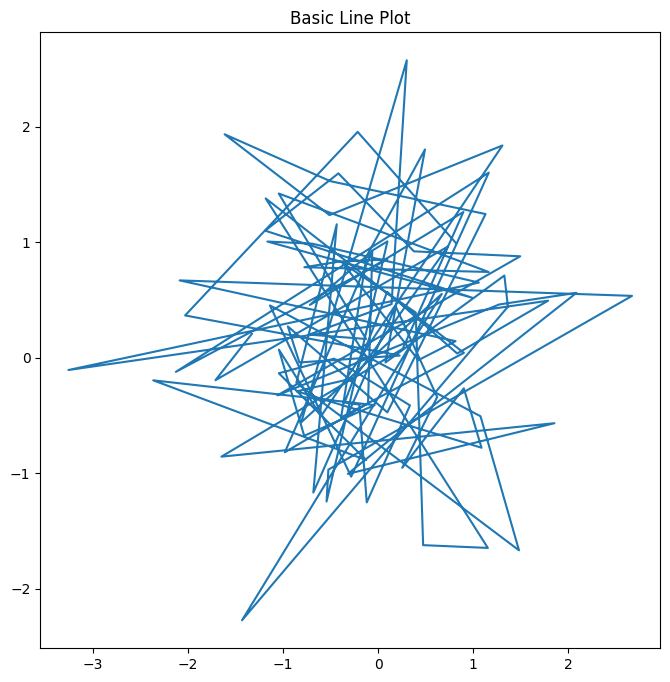

In [50]:
from matplotlib.pyplot import subplots
import numpy as np

# Generate reproducible sample data for plotting examples.
rng = np.random.default_rng(1303)
x = rng.standard_normal(100)
y = rng.standard_normal(100)

def plot_basic_function(x_values, y_values, figsize=(8, 8)):
    """Create a basic line plot and return the figure/axes objects."""
    fig, ax = subplots(figsize=figsize)
    ax.plot(x_values, y_values)
    ax.set_title("Basic Line Plot")
    return fig, ax

# Run the first plotting example.
fig_basic, ax_basic = plot_basic_function(x, y)
fig_basic;

### 2. Scatter Plots
A scatter plot helps inspect pairwise relationships between variables. We encapsulate formatting choices in a dedicated function for consistency.

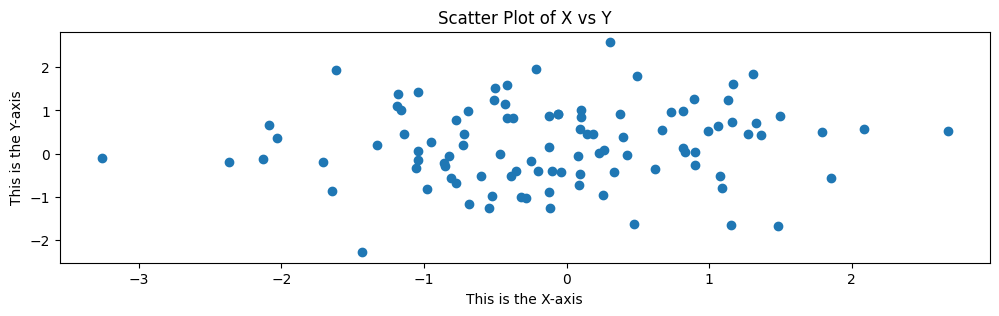

In [51]:
def create_scatter_analysis(x_values, y_values, figsize=(8, 8), marker_style='o'):
    """Create a scatter plot and return the figure/axes objects."""
    fig, ax = subplots(figsize=figsize)
    ax.scatter(x_values, y_values, marker=marker_style)
    ax.set_xlabel("This is the X-axis")
    ax.set_ylabel("This is the Y-axis")
    ax.set_title("Scatter Plot of X vs Y")
    return fig, ax

# Run the scatter plotting example.
fig_scatter, ax_scatter = create_scatter_analysis(x, y)
fig_scatter.set_size_inches(12, 3)
fig_scatter;

### 3. Multi-Panel Layout and Figure Export
Subplots are useful for comparing multiple visual views in one figure. We also include a reusable export helper for saving outputs.

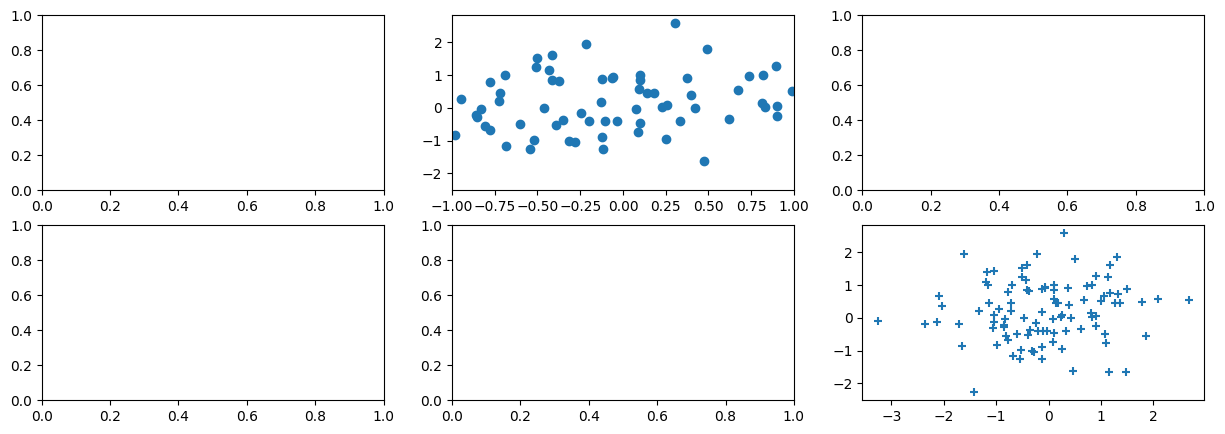

In [52]:
def create_subplot_gallery(x_values, y_values, nrows=2, ncols=3, figsize=(15, 5)):
    """Create a grid of subplots and place sample charts in selected panels."""
    fig, axes = subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes[0, 1].plot(x_values, y_values, 'o')
    axes[1, 2].scatter(x_values, y_values, marker='+')
    return fig, axes

def export_figure_examples(fig, axes):
    """Save the figure in multiple formats and update one axis limit."""
    fig.savefig("Figure.png", dpi=400)
    fig.savefig("Figure.pdf", dpi=200)
    axes[0, 1].set_xlim([-1, 1])
    fig.savefig("Figure_updated.jpg")

# Run the multi-panel example and export outputs.
fig_grid, axes_grid = create_subplot_gallery(x, y)
export_figure_examples(fig_grid, axes_grid)
fig_grid;

### 4. Contour and Image Maps
Contour plots and image maps are useful to visualize functions defined over a 2D grid. We package grid creation and plotting in reusable helpers.

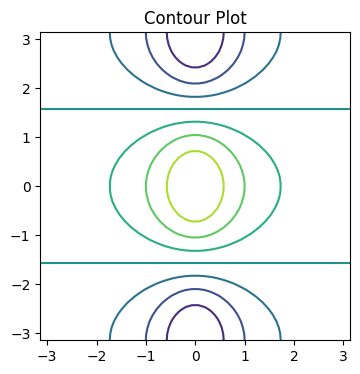

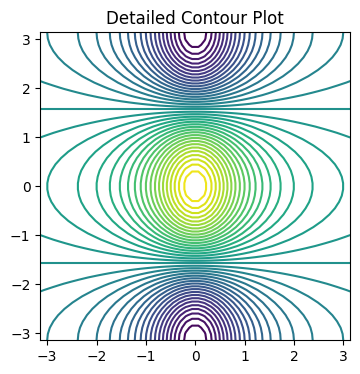

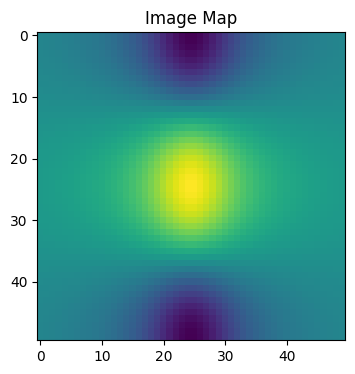

In [55]:
def build_surface_data(n_points=50):
    """Build a 2D grid and surface values for contour/image plotting."""
    x_grid = np.linspace(-np.pi, np.pi, n_points)
    y_grid = x_grid
    f_grid = np.multiply.outer(np.cos(y_grid), 1 / (1 + x_grid**2))
    return x_grid, y_grid, f_grid

def plot_contour_maps(x_grid, y_grid, f_grid):
    """Create contour visualizations with default and detailed levels."""
    fig_default, ax_default = subplots(figsize=(4, 4))
    ax_default.contour(x_grid, y_grid, f_grid)
    ax_default.set_title("Contour Plot")

    fig_detailed, ax_detailed = subplots(figsize=(4, 4))
    ax_detailed.contour(x_grid, y_grid, f_grid, levels=45)
    ax_detailed.set_title("Detailed Contour Plot")
    return (fig_default, ax_default), (fig_detailed, ax_detailed)

def plot_image_map(f_grid):
    """Display the 2D surface as an image map."""
    fig, ax = subplots(figsize=(4, 4))
    ax.imshow(f_grid)
    ax.set_title("Image Map")
    return fig, ax

# Run contour/image examples.
x_grid, y_grid, f_grid = build_surface_data()
(fig_contour, ax_contour), (fig_contour_detailed, ax_contour_detailed) = plot_contour_maps(
    x_grid, y_grid, f_grid
)
fig_image, ax_image = plot_image_map(f_grid)
fig_image;